# Topic and Category Quality Report

This notebook evaluates AI-generated topics and assigned categories from Mongo `youtube_channel_videos`.

## Outputs
- Coverage and distribution metrics
- Topic/category summaries
- Redundancy and consistency checks
- Co-occurrence diagnostics
- CSV exports for supervisor reporting

In [3]:
# Optional one-time dependency bootstrap (run only if imports fail).
import sys
!{sys.executable} -m pip install pymongo neo4j scikit-learn openai python-dotenv pandas numpy matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import os
from dotenv import load_dotenv

load_dotenv("/opt/airflow/.env", override=True)
print(os.getenv("MONGODB_URI"))

<REDACTED_MONGODB_URI>


In [5]:
import os
from collections import Counter

import numpy as np  # pyright: ignore[reportMissingImports]
import pandas as pd  # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt  # pyright: ignore[reportMissingImports]
from pymongo import MongoClient  # pyright: ignore[reportMissingImports]
from sklearn.feature_extraction.text import TfidfVectorizer  # pyright: ignore[reportMissingImports]
from sklearn.metrics.pairwise import cosine_similarity  # pyright: ignore[reportMissingImports]

try:
    from dotenv import load_dotenv  # pyright: ignore[reportMissingImports]
    load_dotenv(".env")
except Exception:
    pass

MONGODB_URI = os.getenv("MONGODB_URI")
MONGODB_DB = os.getenv("MONGODB_DB", "rbl")
MONGO_VIDEOS_COLLECTION = os.getenv("MONGO_VIDEOS_COLLECTION", "youtube_channel_videos")

# Output directory for report artifacts.
OUTPUT_DIR = os.getenv("TOPIC_REPORT_OUTPUT_DIR", "/opt/airflow/notebooks/outputs/topic_quality_report")
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not MONGODB_URI:
    raise ValueError("Set MONGODB_URI in environment first.")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 140)
print("output dir:", OUTPUT_DIR)

output dir: /opt/airflow/notebooks/outputs/topic_quality_report


In [6]:
# Load video documents from Mongo.
mongo = MongoClient(MONGODB_URI)
coll = mongo[MONGODB_DB][MONGO_VIDEOS_COLLECTION]

query = {"video_id": {"$exists": True, "$nin": [None, ""]}}
projection = {
    "_id": 0,
    "video_id": 1,
    "channel_title": 1,
    "comments_analysis_model": 1,
    "comments_analyzed_at": 1,
    "comments_count_relevance": 1,
    "comments_frequent_topics": 1,
    "comments_frequent_topic_categories": 1,
    "comments_frequent_topic_weights": 1,
}

docs = list(coll.find(query, projection=projection))
mongo.close()

videos_df = pd.DataFrame(docs)
if "comments_count_relevance" not in videos_df.columns:
    videos_df["comments_count_relevance"] = 0
videos_df["comments_count_relevance"] = pd.to_numeric(videos_df["comments_count_relevance"], errors="coerce").fillna(0).astype(int)

videos_with_topics = videos_df["comments_frequent_topics"].apply(lambda x: isinstance(x, list) and len(x) > 0)
videos_topics_df = videos_df.loc[videos_with_topics].copy()
videos_with_relevance = videos_topics_df["comments_count_relevance"] > 0

print("videos loaded (all):", len(videos_df))
print("videos in report scope (with topics):", len(videos_topics_df))
print("scope videos with comments_count_relevance > 0:", int(videos_with_relevance.sum()))
print("scope videos with comments_count_relevance = 0:", int((~videos_with_relevance).sum()))

/tmp/ipykernel_41/827753020.py:2: UserWarning: You appear to be connected to a CosmosDB cluster. For more information regarding feature compatibility and support please visit https://www.mongodb.com/supportability/cosmosdb
  mongo = MongoClient(MONGODB_URI)


videos loaded (all): 25803
videos in report scope (with topics): 24953
scope videos with comments_count_relevance > 0: 24953
scope videos with comments_count_relevance = 0: 0


In [7]:
# Flatten per-video arrays to row-level topic records.
rows = []
for _, r in videos_topics_df.iterrows():
    video_id = str(r.get("video_id", "")).strip()
    if not video_id:
        continue

    topics = r.get("comments_frequent_topics") or []
    cats = r.get("comments_frequent_topic_categories") or []
    weights = r.get("comments_frequent_topic_weights") or []

    if not isinstance(topics, list):
        continue

    for i, t in enumerate(topics):
        topic = str(t or "").strip()
        if not topic:
            continue

        cat = str(cats[i] if isinstance(cats, list) and i < len(cats) else "").strip()
        try:
            w = float(weights[i]) if isinstance(weights, list) and i < len(weights) else 0.0
        except Exception:
            w = 0.0

        rows.append(
            {
                "video_id": video_id,
                "channel_title": r.get("channel_title"),
                "model": r.get("comments_analysis_model"),
                "analyzed_at": r.get("comments_analyzed_at"),
                "comments_count_relevance": int(r.get("comments_count_relevance") or 0),
                "topic": topic,
                "category": cat if cat else "<missing>",
                "weight": w,
            }
        )

topic_rows = pd.DataFrame(rows)
print("flattened topic rows:", len(topic_rows))
print("unique topics:", topic_rows["topic"].nunique())
print("unique categories:", topic_rows["category"].nunique())
print("min comments_count_relevance in analysis set:", int(topic_rows["comments_count_relevance"].min()) if not topic_rows.empty else 0)
topic_rows.head(5)

flattened topic rows: 198456
unique topics: 153192
unique categories: 17912
min comments_count_relevance in analysis set: 1


,video_id,channel_title,model,analyzed_at,comments_count_relevance,topic,category,weight
0,K_CbgLpvH9E,MrBeast,gpt-4.1,2026-03-11 20:35:25.742,1000,Solitary Confinement Challenge,Challenge,1.00
1,K_CbgLpvH9E,MrBeast,gpt-4.1,2026-03-11 20:35:25.742,1000,Mental Health Risks,Wellbeing,0.54
2,K_CbgLpvH9E,MrBeast,gpt-4.1,2026-03-11 20:35:25.742,1000,Entertainment Value,Entertainment,0.38
3,K_CbgLpvH9E,MrBeast,gpt-4.1,2026-03-11 20:35:25.742,1000,MrBeast's Dedication,Creator,0.36
4,K_CbgLpvH9E,MrBeast,gpt-4.1,2026-03-11 20:35:25.742,1000,Counting and Boredom,Coping,0.29


In [8]:
# 1) Descriptive metrics.
covered_videos = topic_rows["video_id"].nunique()
all_videos = videos_topics_df["video_id"].nunique()
coverage = covered_videos / all_videos if all_videos else 0.0

per_video_topic_count = topic_rows.groupby("video_id")["topic"].count().rename("topics_per_video")
avg_topics_per_video = float(per_video_topic_count.mean()) if len(per_video_topic_count) else 0.0

# Per-video category volume (unique categories per video).
per_video_category_count = topic_rows.groupby("video_id")["category"].nunique().rename("categories_per_video")
avg_categories_per_video = float(per_video_category_count.mean()) if len(per_video_category_count) else 0.0

topic_stats = (
    topic_rows.groupby("topic", as_index=False)
    .agg(
        videos_count=("video_id", "nunique"),
        total_weight=("weight", "sum"),
        mean_weight=("weight", "mean"),
    )
    .sort_values("total_weight", ascending=False)
)

category_stats = (
    topic_rows.groupby("category", as_index=False)
    .agg(
        videos_count=("video_id", "nunique"),
        rows_count=("topic", "count"),
        total_weight=("weight", "sum"),
    )
    .sort_values("total_weight", ascending=False)
)

print(f"coverage (videos with topics): {covered_videos}/{all_videos} ({coverage:.2%})")
print("average topics/video:", round(avg_topics_per_video, 2))
print("median topics/video:", per_video_topic_count.median())
print("p90 topics/video:", per_video_topic_count.quantile(0.90))
print("average categories/video:", round(avg_categories_per_video, 2))
print("median categories/video:", per_video_category_count.median())
print("p90 categories/video:", per_video_category_count.quantile(0.90))
print("\nTop topics by total_weight")
display(topic_stats.head(20))
print("\nTop categories by total_weight")
display(category_stats.head(20))

coverage (videos with topics): 24953/24953 (100.00%)
average topics/video: 7.95
median topics/video: 8.0
p90 topics/video: 10.0
average categories/video: 7.03
median categories/video: 7.0
p90 categories/video: 10.0

Top topics by total_weight


,topic,videos_count,total_weight,mean_weight
65561,Humor and Laughter,332,104.710,0.315392
65602,Humor and Memes,637,84.050,0.131947
103321,Positive Feedback,327,71.835,0.219679
115457,Requests for More Content,466,70.100,0.150429
65235,Humor,205,57.100,0.278537
86909,Motivation and Inspiration,168,50.120,0.298333
115824,Requests for More Videos,254,43.410,0.170906
144572,Video Appreciation,211,42.970,0.203649
65480,Humor and Entertainment,181,42.520,0.234917
50600,Fortnite Gameplay,169,41.390,0.244911



Top categories by total_weight


,category,videos_count,rows_count,total_weight
2740,Community,9479,12501,1979.725
5184,Entertainment,5557,6046,1268.330
7454,Gameplay,2772,4047,967.540
5147,Engagement,4700,5451,861.730
7762,Gaming,2439,3252,793.670
3328,Content,1933,2387,530.390
14497,Sentiment,2581,2760,519.240
3886,Creator,1595,1774,500.070
8757,Humor,2189,2458,468.330
12269,Personality,1225,1407,375.210


In [9]:
# 1b) Simple lexical normalization for topic-label fragmentation.
import re


def normalize_topic_label(topic: str) -> str:
    """Build a lightweight canonical key from a topic label.

    This is intentionally lexical (not embedding-based): lowercase, strip punctuation,
    drop common connector words, singularize simple plurals, and sort tokens so
    reorderings like 'Humor and Laughter' / 'Laughter and Humor' collapse together.
    """
    if not isinstance(topic, str):
        return "<missing>"

    text = topic.lower().strip()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [t for t in text.split() if t]

    # Drop weak connector tokens that do not carry topic meaning.
    stop_tokens = {
        "and", "or", "the", "a", "an", "of", "for", "to", "in", "on", "with", "about"
    }

    cleaned = []
    for t in tokens:
        if t in stop_tokens:
            continue
        # Naive singularization for simple plural forms.
        if len(t) > 3 and t.endswith("s") and not t.endswith("ss"):
            t = t[:-1]
        cleaned.append(t)

    if not cleaned:
        return "<empty>"

    return " ".join(sorted(set(cleaned)))


topic_rows_norm = topic_rows.copy()
topic_rows_norm["topic_norm_key"] = topic_rows_norm["topic"].apply(normalize_topic_label)

raw_unique_topics = int(topic_rows_norm["topic"].nunique())
norm_unique_topics = int(topic_rows_norm["topic_norm_key"].nunique())

norm_topic_stats = (
    topic_rows_norm.groupby("topic_norm_key", as_index=False)
    .agg(
        videos_count=("video_id", "nunique"),
        total_weight=("weight", "sum"),
        mean_weight=("weight", "mean"),
        raw_topic_labels=("topic", lambda s: sorted(set(s))),
    )
    .sort_values("total_weight", ascending=False)
)

norm_topic_stats["raw_label_count"] = norm_topic_stats["raw_topic_labels"].apply(len)
norm_topic_stats["example_labels"] = norm_topic_stats["raw_topic_labels"].apply(lambda xs: "; ".join(xs[:5]))

print("raw unique topics:", raw_unique_topics)
print("normalized topic keys:", norm_unique_topics)
if raw_unique_topics > 0:
    print("reduction:", f"{(1 - norm_unique_topics / raw_unique_topics):.2%}")

print("\nTop normalized topics by total_weight")
display(norm_topic_stats[["topic_norm_key", "videos_count", "total_weight", "mean_weight", "raw_label_count", "example_labels"]].head(20))

print("\nMost fragmented normalized keys (many raw labels merged)")
display(norm_topic_stats.sort_values("raw_label_count", ascending=False)[["topic_norm_key", "raw_label_count", "example_labels", "videos_count", "total_weight"]].head(20))

raw unique topics: 153192
normalized topic keys: 135589
reduction: 11.49%

Top normalized topics by total_weight


,topic_norm_key,videos_count,total_weight,mean_weight,raw_label_count,example_labels
112606,humor laughter,471,149.840,0.318132,12,Humor & Laughter; Humor & laughter; Humor / Laughter; Humor and Laughter; Humor and laughter
112655,humor meme,807,105.090,0.130223,9,Humor & Memes; Humor / Memes; Humor and Memes; Humor and memes; Humor/Memes
97793,feedback positive,356,78.425,0.220295,2,Positive Feedback; Positive feedback
68740,content more request,498,74.610,0.149819,5,More Content Requests; Request for More Content; Requests For More Content; Requests for More Content; Requests for more content
115104,inspiration motivation,220,66.670,0.303045,9,Inspiration & Motivation; Inspiration / Motivation; Inspiration and Motivation; Inspiration and motivation; Inspiration/Motivation
112530,humor joke,374,61.470,0.164358,13,Humor & Jokes; Humor / Jokes; Humor and In-jokes; Humor and Jokes; Humor and jokes
112435,humor,205,57.100,0.278537,1,Humor
102863,funny humor moment,224,52.880,0.236071,12,Funny Moments & Humor; Funny Moments / Humor; Funny Moments and Humor; Funny Moments/Humor; Funny moments and humor
89967,entertainment humor,235,51.070,0.217319,7,Entertainment and Humor; Entertainment and humor; Entertainment/Humor; Humor & Entertainment; Humor and Entertainment
125671,more request video,293,50.750,0.173208,4,Request for More Videos; Request for more videos; Requests for More Videos; Requests for more videos



Most fragmented normalized keys (many raw labels merged)


,topic_norm_key,raw_label_count,example_labels,videos_count,total_weight
59783,comment early first,29,"""First"" and early comments; Early & First Comments; Early / First Comments; Early Comments & Firsts; Early Comments / First",174,16.52
59798,comment early first viewer,23,Early Comments/First Viewer; Early Viewers / 'First' Comments; Early Viewers / First Comments; Early Viewers and First Comments; Early V...,77,8.51
20155,appreciation fan support,22,Appreciation & Fan Support; Appreciation and Fan Support; Appreciation and fan support; Fan Appreciation & Support; Fan Appreciation / S...,213,38.31
97826,feedback positive video,21,Positive Feedback About Video; Positive Feedback About Videos; Positive Feedback about Video; Positive Feedback about Videos; Positive F...,101,18.16
60049,comment first like,18,First Comment / Likes; First Comment/Like; First Comment/Likes; First Comments & Likes; First Comments and Likes,51,4.23
122052,luck opening pack,17,Luck and Pack Openings; Luck in Pack Opening; Luck in Pack Openings; Luck/Pack Openings; Opening Packs (Pack Luck),50,13.73
84951,dynamic friendship group,17,Friendship & Group Dynamics; Friendship and Group Dynamic; Friendship and Group Dynamics; Friendship and group dynamic; Friendship and g...,68,17.29
20393,appreciation jennie jisoo lisa member ros,16,"Appreciation for Members (Jisoo, Lisa, Jennie, Rosé); Appreciation for Members (Lisa, Jennie, Jisoo, Rosé); Appreciation for Members (Ro...",20,10.11
37856,bot comment spam,16,Bot Comments and Spam; Bot Comments/Spam; Bot comments and spam; Bot/Spam Comments; Bots / Spam Comments,58,5.85
72388,creator praise support,15,Creator Praise and Support; Creator Support and Praise; Praise and Support for Creator; Praise and Support for Creators; Praise and Supp...,42,5.98


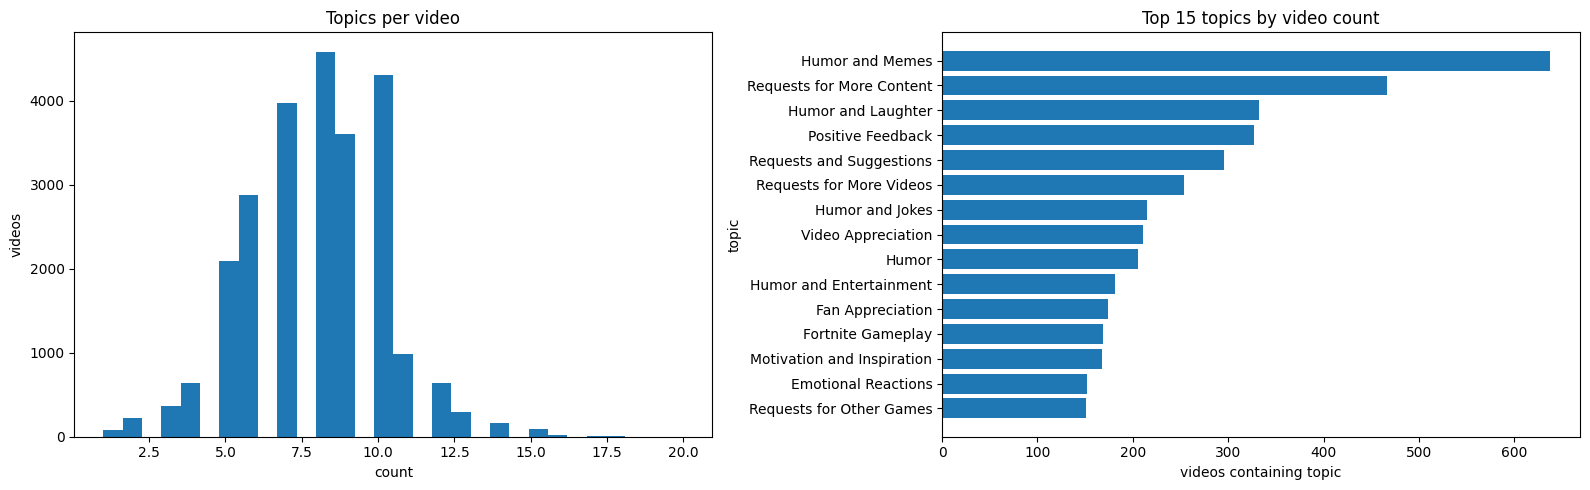

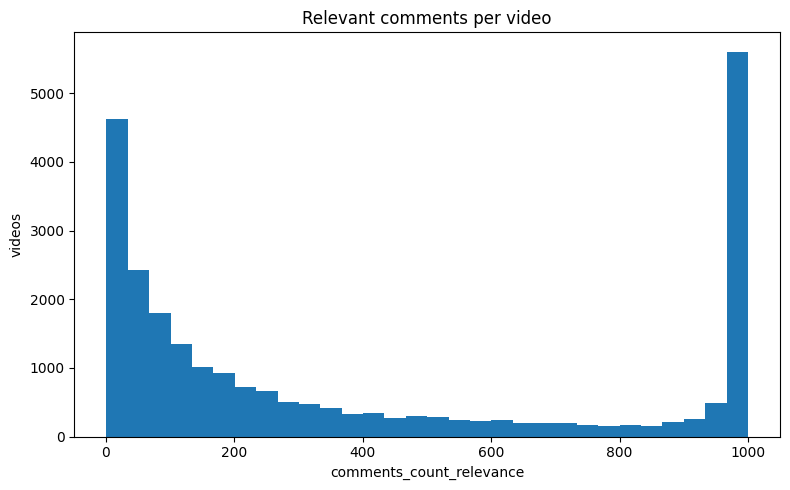

comments_count_relevance summary


count    24953.000000
mean       403.512083
std        394.377838
min          1.000000
10%         14.000000
25%         55.000000
50%        215.000000
75%        916.000000
90%       1000.000000
max       1000.000000
Name: comments_count_relevance, dtype: float64

saved standalone plot: /opt/airflow/notebooks/outputs/topic_quality_report/relevant_comments_per_video.png


In [ ]:
# 2) Distribution plots (simplified).
# Keep histogram outputs as separate standalone figures for reporting/slides.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(per_video_topic_count.values, bins=30)
axes[0].set_title("Topics per video")
axes[0].set_xlabel("count")
axes[0].set_ylabel("videos")

# Easier-to-read alternative to log-log long-tail.
top_topics = (
    topic_rows.groupby("topic")["video_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
    .sort_values(ascending=True)
)
axes[1].barh(top_topics.index, top_topics.values)
axes[1].set_title("Top 15 topics by video count")
axes[1].set_xlabel("videos containing topic")
axes[1].set_ylabel("topic")

plt.tight_layout()

distribution_panel_path = os.path.join(OUTPUT_DIR, "distribution_panel.png")
fig.savefig(distribution_panel_path, dpi=180, bbox_inches="tight")
plt.show()

# Standalone chart: how many topics each processed video has.
fig_topics, ax_topics = plt.subplots(figsize=(8, 5))
ax_topics.hist(per_video_topic_count.values, bins=30)
ax_topics.set_title("Topics per video")
ax_topics.set_xlabel("topics_per_video")
ax_topics.set_ylabel("videos")
plt.tight_layout()

topics_hist_path = os.path.join(OUTPUT_DIR, "topics_per_video.png")
fig_topics.savefig(topics_hist_path, dpi=180, bbox_inches="tight")
plt.show()

# Standalone chart: how many relevant comments each processed video has.
# Keep population consistent with topic analysis: only videos that have topics.
comment_counts = videos_topics_df["comments_count_relevance"].dropna()

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.hist(comment_counts.values, bins=30)
ax2.set_title("Relevant comments per video")
ax2.set_xlabel("comments_count_relevance")
ax2.set_ylabel("videos")
plt.tight_layout()

relevant_hist_path = os.path.join(OUTPUT_DIR, "relevant_comments_per_video.png")
fig2.savefig(relevant_hist_path, dpi=180, bbox_inches="tight")
plt.show()

print("comments_count_relevance summary")
display(comment_counts.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))
print("saved standalone plots:", topics_hist_path, "and", relevant_hist_path)

In [11]:
# 3) Overall entropy summary (all scoped videos with topics)
def shannon_entropy(ws):
    arr = np.array(ws, dtype=float)
    arr = arr[arr > 0]
    if arr.size == 0:
        return 0.0
    p = arr / arr.sum()
    return float(-(p * np.log2(p)).sum())

video_entropy = (
    topic_rows.groupby("video_id")["weight"]
    .apply(shannon_entropy)
    .rename("topic_entropy")
)

print("Entropy summary")
display(video_entropy.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

Entropy summary


count    24953.000000
mean         2.633816
std          0.474822
min         -0.000000
10%          2.102947
25%          2.392813
50%          2.681766
75%          2.958396
90%          3.152794
max          4.272240
Name: topic_entropy, dtype: float64

Topic diversity by comments_count_relevance bucket


,comment_bucket,videos,mean_diversity,median_diversity,p10,p90
0,1-10,1963,1.789869,1.926121,1.000000,2.301901
1,11-50,3949,2.402074,2.419169,2.077422,2.746032
2,51-200,6235,2.646598,2.665030,2.273023,3.015627
3,200+,12806,2.828422,2.876357,2.351490,3.245177


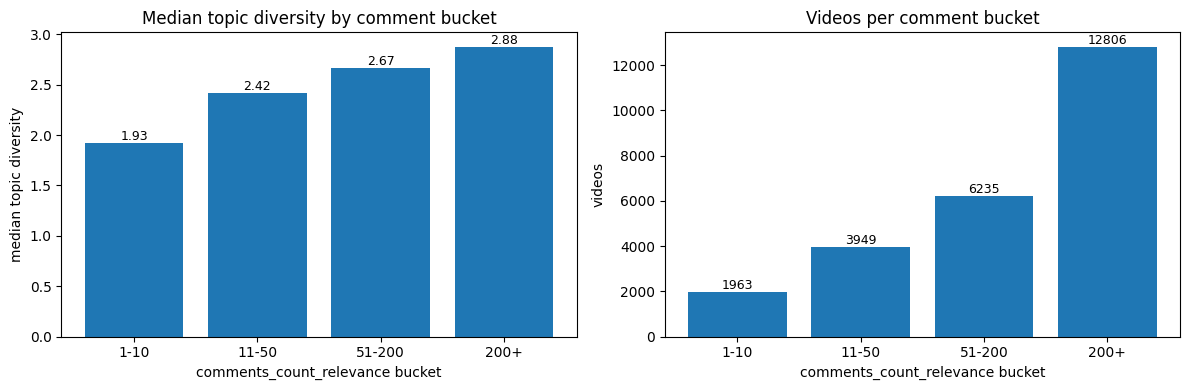

In [12]:
# 3b) Topic diversity by relevant-comment-count bucket.
# Helps interpret whether low topic diversity is evidence of focus or just low sample size.

per_video_comments = (
    topic_rows.groupby("video_id")["comments_count_relevance"]
    .max()
    .rename("comments_count_relevance")
)

entropy_with_comments = pd.concat([video_entropy, per_video_comments], axis=1).dropna()

bins = [0, 10, 50, 200, np.inf]
labels = ["1-10", "11-50", "51-200", "200+"]
entropy_with_comments["comment_bucket"] = pd.cut(
    entropy_with_comments["comments_count_relevance"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

bucket_summary = (
    entropy_with_comments.groupby("comment_bucket", observed=True)["topic_entropy"]
    .agg(
        videos="count",
        mean_diversity="mean",
        median_diversity="median",
        p10=lambda s: s.quantile(0.10),
        p90=lambda s: s.quantile(0.90),
    )
    .reset_index()
)

print("Topic diversity by comments_count_relevance bucket")
display(bucket_summary)

# Simpler visualization: median topic diversity + sample size per bucket.
plot_df = bucket_summary.copy()
plot_df["comment_bucket"] = pd.Categorical(plot_df["comment_bucket"], categories=labels, ordered=True)
plot_df = plot_df.sort_values("comment_bucket")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(plot_df["comment_bucket"].astype(str), plot_df["median_diversity"])
axes[0].set_title("Median topic diversity by comment bucket")
axes[0].set_xlabel("comments_count_relevance bucket")
axes[0].set_ylabel("median topic diversity")
for i, v in enumerate(plot_df["median_diversity"]):
    axes[0].text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)

axes[1].bar(plot_df["comment_bucket"].astype(str), plot_df["videos"])
axes[1].set_title("Videos per comment bucket")
axes[1].set_xlabel("comments_count_relevance bucket")
axes[1].set_ylabel("videos")
for i, v in enumerate(plot_df["videos"]):
    axes[1].text(i, v + max(plot_df["videos"]) * 0.01, f"{int(v)}", ha="center", fontsize=9)

plt.tight_layout()

diversity_bucket_plot_path = os.path.join(OUTPUT_DIR, "topic_diversity_by_relevance_bucket.png")
fig.savefig(diversity_bucket_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print("saved plot:", diversity_bucket_plot_path)

low-entropy threshold: 2.1029
videos in focused subset: 2496
focused subset comments_count_relevance summary


count    2496.000000
mean      186.377003
std       334.538952
min         1.000000
10%         2.000000
25%         4.000000
50%        12.000000
75%       147.000000
90%       978.000000
max      1000.000000
Name: comments_count_relevance, dtype: float64

focused subset by comments_count_relevance bucket


,videos
comment_bucket,
1-10,1204
11-50,456
51-100,144
101-300,204
301-600,113
601-1000,375


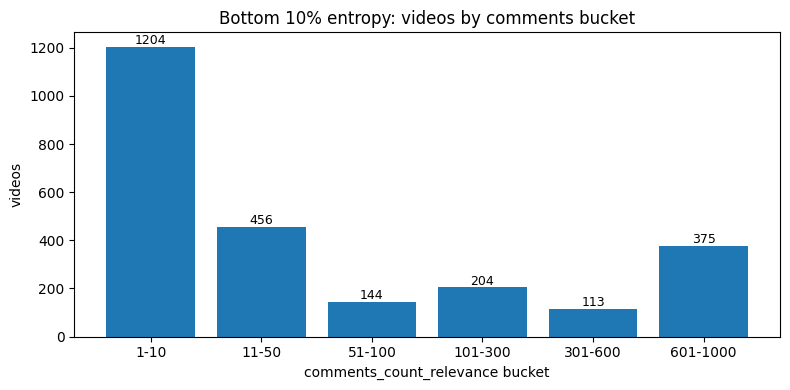


Bucket 1-10 - videos: 1204


dominant_topic
Humor                          38
Positive Feedback              33
Livestream Quality             22
Greetings                      18
Livestream Enjoyment           12
Laughter                       12
Positive Feedback on Stream    11
Stream Quality                 11
Humor and Laughter             11
Positive Reactions             10
Name: count, dtype: int64

dominant_category
Engagement          130
Entertainment        63
Emotion              56
Feedback             26
Appreciation         23
Content Feedback     22
Community            20
Sports               19
Fishing              18
Emotions             18
Name: count, dtype: int64


Bucket 11-50 - videos: 456


dominant_topic
Humor and Laughter      17
Humor                    8
Laughter and Humor       7
Galatasaray              4
Galatasaray Support      4
Feyenoord Support        4
Player Pack Luck         3
Player Pack Openings     3
Ajax Support             3
Positive Reactions       3
Name: count, dtype: int64

...

dominant_topic
Crainer's Return            6
School                      3
Cheese (Kaas)               2
Watermelon                  2
Favorite Colors             2
Subscribing                 2
Pineapple on Pizza          2
Phone Battery Percentage    2
Singing Talent              2
Pizza                       2
Name: count, dtype: int64

dominant_category
Engagement             13
Humor                   9
Food                    6
Gameplay                5
Celebration             5
Video Interaction       5
Audience Engagement     4
Community Support       4
Game Mechanics          4
Character               4
Name: count, dtype: int64

,video_id,dominant_topic,dominant_category,dominant_weight,comments_count_relevance,comment_bucket
10,-CiNGhu9nRo,Being First to Comment,Engagement,1.0,1,1-10
16,-N6ckeor4ks,Drone Fishing,Recreation,1.0,1,1-10
19,-O3y3mi0Bjg,Positive Feedback,Reception,1.0,1,1-10
45,05yD3zXhV8E,Winning Against PSV,Sports Outcome,1.0,1,1-10
82,1Kz1XZSrufg,First Comment,Engagement,1.0,1,1-10
154,32uOv9wFXAo,HPF Vibes,Nostalgia,1.0,1,1-10
192,43HpUQzM2kw,Request for Continuation,Engagement,1.0,1,1-10
195,47ecSooPdDc,Legends,Praise,1.0,1,1-10
198,4AYKpxCQ2RQ,Insult,Behavior,1.0,1,1-10
235,56bWL6TOB-Q,Positive Feedback,Viewer Reaction,1.0,1,1-10


dominant_topic
Humor                          46
Positive Feedback              36
Humor and Laughter             30
Livestream Quality             23
Greetings                      19
Laughter and Humor             17
Livestream Enjoyment           14
Positive Reactions             13
Laughter                       13
Stream Quality                 13
Positive Feedback on Stream    11
Subscribing                    10
Livestream Appreciation        10
Player Pack Results             8
Stream Appreciation             8
Crainer's Return                7
Positive Stream Feedback        7
Appreciation                    7
Player Pack Openings            6
Feyenoord Support               6
Name: count, dtype: int64

dominant_category
Engagement          179
Entertainment       103
Gameplay             69
Emotion              64
Humor                44
Gaming               40
Community            31
Sports               30
Feedback             29
Personality          29
Appreciation         28
Content Feedback     25
Food                 24
Content              23
Celebration          22
Emotions             21
Sentiment            21
Fishing              21
Music                19
Performance          19
Name: count, dtype: int64

In [13]:
# Join entropy with topic rows and find dominant topic per low-entropy videos.
# Includes comments_count_relevance and granular buckets for evidence-strength context.
low_thr = video_entropy.quantile(0.10)  # bottom 10% entropy
low_entropy_videos = set(video_entropy[video_entropy <= low_thr].index)

per_video_comments = (
    topic_rows.groupby("video_id")["comments_count_relevance"]
    .max()
    .rename("comments_count_relevance")
    .reset_index()
)

dominant = (
    topic_rows[topic_rows["video_id"].isin(low_entropy_videos)]
    .sort_values(["video_id", "weight"], ascending=[True, False])
    .groupby("video_id", as_index=False)
    .first()[["video_id", "topic", "category", "weight"]]
    .rename(columns={"topic": "dominant_topic", "category": "dominant_category", "weight": "dominant_weight"})
    .merge(per_video_comments, on="video_id", how="left")
)

print("low-entropy threshold:", round(float(low_thr), 4))
print("videos in focused subset:", len(dominant))
print("focused subset comments_count_relevance summary")
display(dominant["comments_count_relevance"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))

focus_bins = [0, 10, 50, 100, 300, 600, 1000]
focus_labels = ["1-10", "11-50", "51-100", "101-300", "301-600", "601-1000"]

dominant["comment_bucket"] = pd.cut(
    dominant["comments_count_relevance"],
    bins=focus_bins,
    labels=focus_labels,
    include_lowest=True,
)
focus_bucket_counts = dominant["comment_bucket"].value_counts().reindex(focus_labels, fill_value=0)

print("focused subset by comments_count_relevance bucket")
display(focus_bucket_counts.rename("videos").to_frame())

plt.figure(figsize=(8, 4))
bars = plt.bar(focus_bucket_counts.index.astype(str), focus_bucket_counts.values)
plt.title("Bottom 10% entropy: videos by comments bucket")
plt.xlabel("comments_count_relevance bucket")
plt.ylabel("videos")
for b, v in zip(bars, focus_bucket_counts.values):
    plt.text(b.get_x() + b.get_width() / 2, v + max(focus_bucket_counts.values.tolist() + [1]) * 0.01, f"{int(v)}", ha="center", fontsize=9)
plt.tight_layout()

low_entropy_bucket_plot_path = os.path.join(OUTPUT_DIR, "low_entropy_videos_by_relevance_bucket.png")
plt.savefig(low_entropy_bucket_plot_path, dpi=180, bbox_inches="tight")
plt.show()
print("saved plot:", low_entropy_bucket_plot_path)

for b in focus_labels:
    d = dominant[dominant["comment_bucket"] == b]
    if d.empty:
        continue
    print(f"\nBucket {b} - videos: {len(d)}")
    display(d["dominant_topic"].value_counts().head(10))
    display(d["dominant_category"].value_counts().head(10))

display(dominant.sort_values(["comments_count_relevance", "dominant_weight"], ascending=[True, False]).head(30))
display(dominant["dominant_topic"].value_counts().head(20))
display(dominant["dominant_category"].value_counts().head(20))

In [14]:
# 4) Redundancy and category consistency proxy via label similarity (ultra-light).
# This version is intentionally conservative to avoid kernel crashes.
if "topic_rows" not in globals():
    raise RuntimeError("topic_rows is not defined. Run the flatten-topics cell first.")

from sklearn.neighbors import NearestNeighbors  # pyright: ignore[reportMissingImports]

unique_topics = topic_rows[["topic", "category"]].drop_duplicates(subset=["topic"]).reset_index(drop=True)
full_n_topics = len(unique_topics)

# Limit analysis to a random topic sample so memory/runtime stays bounded.
sample_topics_n = 8000
sampled_topics = unique_topics.sample(n=min(sample_topics_n, full_n_topics), random_state=42).reset_index(drop=True)

vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=80000)
X = vec.fit_transform(sampled_topics["topic"])
n_topics = X.shape[0]

near_dup_threshold = 0.85
max_neighbors = 8
k = min(max_neighbors, n_topics)

# 4a) Approx near-duplicate detection on sampled topics only.
if k <= 1:
    near_dup_df = pd.DataFrame(columns=["topic_a", "cat_a", "topic_b", "cat_b", "similarity"])
else:
    nn = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=k)
    nn.fit(X)
    distances, indices = nn.kneighbors(X)

    seen_pairs = set()
    near_dup_rows = []
    for i in range(n_topics):
        for rank in range(1, k):  # rank 0 is self
            j = int(indices[i, rank])
            sim = 1.0 - float(distances[i, rank])
            if sim < near_dup_threshold:
                continue
            a, b = (i, j) if i < j else (j, i)
            if a == b or (a, b) in seen_pairs:
                continue
            seen_pairs.add((a, b))
            near_dup_rows.append(
                {
                    "topic_a": sampled_topics.loc[a, "topic"],
                    "cat_a": sampled_topics.loc[a, "category"],
                    "topic_b": sampled_topics.loc[b, "topic"],
                    "cat_b": sampled_topics.loc[b, "category"],
                    "similarity": sim,
                }
            )

    near_dup_df = pd.DataFrame(near_dup_rows)
    if len(near_dup_df):
        near_dup_df = near_dup_df.sort_values("similarity", ascending=False).reset_index(drop=True)

print(f"topics total: {full_n_topics}, sampled: {n_topics}, neighbors per topic: {k}")
print("near-duplicate topic pairs (>=0.85) in sample:", len(near_dup_df))
display(near_dup_df.head(30))

# 4b) Category consistency from sampled pairs (sampled topics only).
rng = np.random.default_rng(42)
cat_vals = sampled_topics["category"].to_numpy()
cat_to_idx = sampled_topics.groupby("category").indices

sample_pairs_target = 5000

within_pairs = set()
valid_cats = [c for c, idx in cat_to_idx.items() if len(idx) >= 2]
attempts = 0
max_attempts = sample_pairs_target * 40
while len(within_pairs) < sample_pairs_target and attempts < max_attempts and valid_cats:
    c = valid_cats[int(rng.integers(0, len(valid_cats)))]
    idx = np.asarray(cat_to_idx[c], dtype=int)
    i, j = rng.choice(idx, size=2, replace=False)
    a, b = (int(i), int(j)) if i < j else (int(j), int(i))
    within_pairs.add((a, b))
    attempts += 1

between_pairs = set()
attempts = 0
all_idx = np.arange(n_topics)
while len(between_pairs) < sample_pairs_target and attempts < max_attempts and n_topics >= 2:
    i, j = rng.choice(all_idx, size=2, replace=False)
    if cat_vals[i] == cat_vals[j]:
        attempts += 1
        continue
    a, b = (int(i), int(j)) if i < j else (int(j), int(i))
    between_pairs.add((a, b))
    attempts += 1


def pair_sims_from_index_pairs(X_sparse, pair_set):
    if not pair_set:
        return np.array([], dtype=float)
    pair_arr = np.array(list(pair_set), dtype=int)
    a_idx = pair_arr[:, 0]
    b_idx = pair_arr[:, 1]
    sims = X_sparse[a_idx].multiply(X_sparse[b_idx]).sum(axis=1).A1
    return sims.astype(float)

within = pair_sims_from_index_pairs(X, within_pairs)
between = pair_sims_from_index_pairs(X, between_pairs)

print("within sample pairs:", len(within), "between sample pairs:", len(between))
print("avg within-category similarity (sample):", round(float(np.mean(within)) if len(within) else 0.0, 4))
print("avg between-category similarity (sample):", round(float(np.mean(between)) if len(between) else 0.0, 4))

topics total: 153192, sampled: 8000, neighbors per topic: 8
near-duplicate topic pairs (>=0.85) in sample: 183


,topic_a,cat_a,topic_b,cat_b,similarity
0,Competitiveness and Fairness,Competition,Fairness and Competitiveness,Sports Integrity,1.000000
1,Live Stream Participation,Community Engagement,Live stream participation,Community Engagement,1.000000
2,Gameplay Questions and Tips,Game Advice,Questions and Gameplay Tips,Game Help,1.000000
3,Behind-the-scenes content,Content,Behind-the-scenes Content,Content,1.000000
4,Ray's Personality and Popularity,Creator,Ray's Popularity and Personality,Creator/Personality,1.000000
5,Achievements in-game,Gaming,In-game Achievements,Player Experience,1.000000
6,Prime energy drink,Drinks,Prime Energy Drink,Brand/Product,1.000000
7,Song addictiveness and replay,Song Impact,Song Addictiveness and Replay,Listener Reaction,1.000000
8,Japan trip,Travel,Japan Trip,Travel,1.000000
9,Events and Meetups,Experiences,Meetups and Events,Community,1.000000


within sample pairs: 5000 between sample pairs: 5000
avg within-category similarity (sample): 0.0699
avg between-category similarity (sample): 0.0121


In [15]:
# 5) Co-occurrence diagnostics.
def top_cooccurrence_pairs(df, col, top_n=30):
    counts = Counter()
    for _, g in df.groupby("video_id"):
        vals = sorted(set(str(v).strip() for v in g[col].dropna().tolist() if str(v).strip()))
        for i in range(len(vals)):
            for j in range(i + 1, len(vals)):
                counts[(vals[i], vals[j])] += 1
    out = pd.DataFrame([
        {"a": a, "b": b, "cooccur_videos": c} for (a, b), c in counts.most_common(top_n)
    ])
    return out

print("Top topic co-occurrence pairs")
display(top_cooccurrence_pairs(topic_rows, "topic", top_n=25))

print("Top category co-occurrence pairs")
display(top_cooccurrence_pairs(topic_rows, "category", top_n=25))

Top topic co-occurrence pairs


,a,b,cooccur_videos
0,Humor and Laughter,Requests for More Content,21
1,Diet and Nutrition,Motivation and Inspiration,18
2,Humor and Laughter,Requests for More Videos,18
3,Fortnite,Minecraft,17
4,Humor and Memes,Requests and Suggestions,17
5,Positive Feedback,Requests for Content,15
6,Humor,Positive Feedback,15
7,Positive Feedback,Requests for More Videos,14
8,Fortnite Gameplay,Humor and Memes,14
9,Humor and Memes,Requests for More Content,14


Top category co-occurrence pairs


,a,b,cooccur_videos
0,Community,Entertainment,2474
1,Community,Engagement,2273
2,Community,Gameplay,1721
3,Community,Gaming,1419
4,Community,Content,1209
5,Community,Feedback,1039
6,Engagement,Entertainment,1035
7,Community,Sentiment,952
8,Community,Creator,945
9,Community,Humor,866


In [16]:
# 7) Compact metrics export for report deck.
report_rows = [
    {"metric": "scope_videos_with_topics", "value": int(all_videos)},
    {"metric": "videos_with_topic_rows", "value": int(covered_videos)},
    {"metric": "coverage_ratio_within_topic_scope", "value": float(coverage)},
    {"metric": "topic_rows", "value": int(len(topic_rows))},
    {"metric": "unique_topics", "value": int(topic_rows["topic"].nunique())},
    {"metric": "unique_categories", "value": int(topic_rows["category"].nunique())},
    {"metric": "median_topics_per_video", "value": float(per_video_topic_count.median())},
    {"metric": "p90_topics_per_video", "value": float(per_video_topic_count.quantile(0.90))},
    {"metric": "avg_within_category_similarity", "value": float(np.mean(within)) if len(within) else 0.0},
    {"metric": "avg_between_category_similarity", "value": float(np.mean(between)) if len(between) else 0.0},
    {"metric": "near_duplicate_pairs_ge_0.85", "value": int(len(near_dup_df))},
]

report_df = pd.DataFrame(report_rows)
report_path = os.path.join(OUTPUT_DIR, "topic_quality_report_metrics.csv")
report_df.to_csv(report_path, index=False)
print("saved metrics csv:", report_path)
display(report_df)

saved metrics csv: /opt/airflow/notebooks/outputs/topic_quality_report/topic_quality_report_metrics.csv


,metric,value
0,scope_videos_with_topics,24953.000000
1,videos_with_topic_rows,24953.000000
2,coverage_ratio_within_topic_scope,1.000000
3,topic_rows,198456.000000
4,unique_topics,153192.000000
5,unique_categories,17912.000000
6,median_topics_per_video,8.000000
7,p90_topics_per_video,10.000000
8,avg_within_category_similarity,0.069874
9,avg_between_category_similarity,0.012111


## Supervisor Report Template

Use this structure to summarize findings.

### 1) Executive Summary
- Number of videos analyzed (scope = videos that already have topics) and topic coverage ratio.
- Main conclusion on topic/category quality (good/moderate/needs cleanup).
- Top 2-3 recommended next actions.

### 2) Data Coverage and Distribution
- Report `scope_videos_with_topics`, `videos_with_topic_rows`, and `coverage_ratio_within_topic_scope`.
- Explicitly report how many videos have `comments_count_relevance > 0` vs `= 0` for context.
- Show `median_topics_per_video` and `p90_topics_per_video`.
- Include the frequency plots to explain concentration (few very frequent topics, many rarer topics).

Interpretation:
- High coverage + stable per-video topic counts = robust extraction behavior.
- Very high p90 vs median may indicate over-generation on a subset of videos.

### 3) Topic and Category Concentration
- Present top topics and top categories by `total_weight`.
- Mention whether dominance is expected (e.g. creator-specific channels) or problematic.

Interpretation:
- Strong concentration can be natural, but may reduce discovery unless merged/normalized.

### 4) Redundancy and Label Quality
- Report `near_duplicate_pairs_ge_0.85` and show top duplicate pairs.
- Call out obvious merge candidates.

Interpretation:
- Large duplicate count implies naming variance from prompting and suggests dedup/normalization layer.

### 5) Category Consistency
- Compare `avg_within_category_similarity` vs `avg_between_category_similarity`.

Interpretation:
- Good hierarchy signal: within-category similarity should be materially higher than between-category.
- If close values: category boundaries may be too broad or inconsistent.

### 6) Co-occurrence Structure
- Show top topic co-occurrence pairs and category co-occurrence pairs.
- Highlight interpretable thematic bundles and suspicious cross-category mixtures.

Interpretation:
- Useful for defining higher-level taxonomies and graph-based navigation.

### 7) Recommendations
- Short-term (1-2 weeks):
  - merge high-similarity duplicate topics
  - tighten category definitions for low-consistency categories
- Mid-term:
  - add normalization layer before clustering
  - add periodic drift monitoring on the same metrics

### 8) Appendix
- Include exported metrics table (`outputs/topic_quality_report/topic_quality_report_metrics.csv`).
- Include top tables/plots generated by this notebook.